In [ ]:
# Phase (I): Test GRPO on Game of 24 — surface drawbacks D1-D4
#
#   D1  CoT redundancy           → track CoT length distribution across training
#   D2  No per-token signal      → (structural; visualised by absence of v_t)
#   D3  Zero-pass@K dead zone    → curate hard puzzles, track which never solve
#   D4  Indiscriminate credit    → inspect failed rollouts that share good prefixes
#
# Phase (II) [later]: swap reward + advantage for velocity / answer-buffer / prefix-buffer
#                     and re-run the same diagnostics to verify the four fixes.

In [ ]:
import os, re, json, random, itertools, math
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Dict, Any, Optional, Tuple

import numpy as np
import torch
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from trl import GRPOTrainer, GRPOConfig

os.environ.setdefault("HF_HUB_ENABLE_HF_TRANSFER", "1")
random.seed(0); np.random.seed(0); torch.manual_seed(0)

MODEL_NAME    = "Qwen/Qwen3-0.6B"
OUTPUT_DIR    = Path("output/game24_grpo_baseline")
ROLLOUT_LOG   = OUTPUT_DIR / "rollouts.jsonl"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Output dir:", OUTPUT_DIR.resolve())

## 2. Game-of-24 &nbsp;·&nbsp; data &nbsp;·&nbsp; rewards

Everything in this section is a thin wrapper around `src.game24utils`:

- **verifier + solver** — `verify_24`, `enumerate_solutions`
- **puzzle pool + buckets** — `build_puzzle_pool`, `bucket_by_difficulty`
- **splits** — `make_splits` (proportion-based; holds out hard puzzles for D3)
- **prompts / datasets** — `SYSTEM_PROMPT`, `to_chat`, `build_datasets`
- **rewards** — `correctness_reward`, `format_reward`

The notebook itself focuses on training, diagnostics, and the velocity-reward
analysis. Algorithm pieces stay here; bookkeeping pieces live in the module.

In [ ]:
from src.game24utils import (
    verify_24, 
    build_puzzle_pool, bucket_by_difficulty, make_splits,
    to_chat, build_datasets,
    _text,  extract_expr,
    correctness_reward, format_reward,
)

# All solvable 4-tuples from digits 1..9, bucketed by # solutions.
puzzles = build_puzzle_pool(max_n=9)
easy, medium, hard = bucket_by_difficulty(puzzles, easy_min=8, hard_max=2)

print(f"Solvable 4-tuples: {len(puzzles)}")
print(f"  easy   (≥8 sols): {len(easy)}")
print(f"  medium (3-7 sols): {len(medium)}")
print(f"  hard   (≤2 sols): {len(hard)}")
print("example hard puzzle:", hard[0] if hard else None)

In [ ]:
# Proportion-based splits.
# - eval_frac: held-out slice of easy+medium for in-distribution eval
# - probe_frac: slice of HARD puzzles held out as the D3 zero-pass@K probe
train_puzzles, eval_puzzles, hard_probe = make_splits(
    easy, medium, hard, eval_frac=0.10, probe_frac=0.40,
)

print(f"train={len(train_puzzles)}, eval={len(eval_puzzles)}, "
      f"probe(hard, held-out)={len(hard_probe)}")

train_ds, eval_ds, probe_ds = build_datasets(train_puzzles, eval_puzzles, hard_probe)
print(train_ds[0])

In [ ]:
# Rewards live in src.game24utils — trajectory-level only (D2 is structural).
# Sanity:
fake = [[{"role": "assistant", "content": "Let me think...\n#### (3+5)*(7-4)"}]]
print("correctness:", correctness_reward(fake, numbers=[[3, 5, 7, 4]]))
print("format    :", format_reward(fake))

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class RolloutLogger:
    """Logs every rollout to JSONL via the reward-fn callback. Returns 0.0 reward."""
    def __init__(self, path: Path, tok):
        self.path = path
        self.tok  = tok
        self.step = 0
        self.path.write_text("")  # truncate

    def __call__(self, completions, numbers, solutions=None, **kwargs):
        with self.path.open("a") as f:
            for i, (c, nums) in enumerate(zip(completions, numbers)):
                text = _text(c)
                expr = extract_expr(text)
                correct = verify_24(list(nums), expr)
                n_tok = len(self.tok.encode(text, add_special_tokens=False))
                f.write(json.dumps({
                    "step": self.step,
                    "idx": i,
                    "numbers": list(nums),
                    "completion": text,
                    "expr": expr,
                    "correct": bool(correct),
                    "n_tokens": int(n_tok),
                }) + "\n")
        self.step += 1
        return [0.0] * len(completions)   # passthrough, contributes nothing

    # Keep TRL happy: it inspects __name__ on reward callables.
    __name__ = "rollout_logger"

rollout_logger = RolloutLogger(ROLLOUT_LOG, tokenizer)
print("Rollout log →", ROLLOUT_LOG)

## 5. Train &nbsp;·&nbsp; vanilla GRPO

Short run (200 steps, 8 generations/prompt) is enough to surface the four
drawbacks. Bump `max_steps` for a longer collapse-watch.

In [ ]:
config = GRPOConfig(
    output_dir=str(OUTPUT_DIR),
    num_generations=8,
    max_completion_length=512,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=5e-6,
    max_steps=200,
    logging_steps=5,
    bf16=True,
    save_strategy="no",
    report_to="none",
    use_vllm=True,
    vllm_mode="colocate",
    vllm_gpu_memory_utilization=0.4,
)

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.bfloat16)

trainer = GRPOTrainer(
    model=model,
    reward_funcs=[correctness_reward, format_reward, rollout_logger],
    args=config,
    train_dataset=train_ds,
)
trainer.train()
print("Done. Rollouts at:", ROLLOUT_LOG)

## 6. Diagnostics — surfacing D1, D3, D4

We load the rollout log and compute four lenses. D2 is structural (there is no
per-token signal to plot) — its absence is the diagnostic.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

rollouts = [json.loads(l) for l in ROLLOUT_LOG.read_text().splitlines() if l.strip()]
df = pd.DataFrame(rollouts)
df["key"] = df["numbers"].apply(lambda x: tuple(sorted(x)))
print(f"{len(df)} rollouts logged across {df['step'].nunique()} reward-fn calls")
df.head(3)

In [ ]:
# ── D1: CoT redundancy — length + pairwise edit-distance of correct rollouts ──
# Length is the obvious probe. A cleaner second signal: among *correct*
# rollouts on the same puzzle, how diverse are the CoT strings?
# Collapse to a single solution form shows up as edit-distance → 0.

agg = df.groupby("step").agg(
    n_tokens_mean=("n_tokens", "mean"),
    n_tokens_p90=("n_tokens", lambda s: np.percentile(s, 90)),
    acc=("correct", "mean"),
).reset_index()

def norm_edit(a: str, b: str) -> float:
    # Cheap token-level proxy: 1 - LCS/max_len, via difflib.
    import difflib
    sm = difflib.SequenceMatcher(None, a, b, autojunk=False)
    return 1.0 - sm.ratio()

ed_rows = []
for (step, key), g in df[df.correct].groupby(["step", "key"]):
    texts = g.completion.tolist()
    if len(texts) < 2: continue
    pairs = [norm_edit(texts[i], texts[j])
             for i in range(len(texts)) for j in range(i+1, len(texts))]
    ed_rows.append({"step": step, "mean_edit": np.mean(pairs), "n_pairs": len(pairs)})
edf = pd.DataFrame(ed_rows)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(agg.step, agg.n_tokens_mean, label="mean")
axes[0].plot(agg.step, agg.n_tokens_p90,  label="p90", linestyle="--")
axes[0].set_xlabel("step"); axes[0].set_ylabel("CoT tokens")
axes[0].set_title("D1 · CoT length"); axes[0].legend()

for ok, label in [(True, "correct"), (False, "incorrect")]:
    sub = df[df.correct == ok].groupby("step").n_tokens.mean()
    axes[1].plot(sub.index, sub.values, label=label)
axes[1].set_xlabel("step"); axes[1].set_ylabel("mean tokens")
axes[1].set_title("D1 · length, split by correctness"); axes[1].legend()

if len(edf):
    axes[2].plot(edf.step, edf.mean_edit)
    axes[2].set_xlabel("step"); axes[2].set_ylabel("mean pairwise edit-distance")
    axes[2].set_title("D1 · diversity of correct CoTs\n(collapse → 0)")
else:
    axes[2].text(0.5, 0.5, "not enough correct rollouts\non same puzzle to measure",
                 ha="center", va="center"); axes[2].axis("off")
plt.tight_layout(); plt.show()

In [ ]:
# ── Diversity probe — motivates the answer buffer A_q (NOT D2) ──
# For each puzzle with ≥1 solution found, how many *distinct* correct
# expressions did the model produce over the whole run? Compared to the
# total number of solutions the puzzle admits.
def canon(expr: str) -> str:
    """Normalise whitespace so "1 + 2" and "1+2" collapse to one form."""
    return re.sub(r"\s+", "", expr)

rows = []
for key, g in df[df.correct].groupby("key"):
    puzzle = next((p for p in train_puzzles if tuple(sorted(p["numbers"])) == key), None)
    if puzzle is None: continue
    unique = len(set(canon(e) for e in g.expr))
    rows.append({"key": key, "unique_found": unique,
                 "total_solutions": puzzle["n_solutions"],
                 "coverage": unique / puzzle["n_solutions"]})
ddf = pd.DataFrame(rows)
if len(ddf):
    print(f"Puzzles with ≥1 solution found: {len(ddf)}")
    print(f"  mean unique solutions found per puzzle: {ddf.unique_found.mean():.2f}")
    print(f"  mean total solutions per puzzle:        {ddf.total_solutions.mean():.2f}")
    print(f"  mean coverage:                          {ddf.coverage.mean():.1%}")
    plt.figure(figsize=(6, 3))
    plt.hist(ddf.coverage, bins=20)
    plt.xlabel("fraction of a puzzle's solutions the model produced")
    plt.ylabel("# puzzles")
    plt.title("Diversity probe — motivates answer buffer A_q\n"
              "(low coverage → model collapses to few solution forms)")
    plt.tight_layout(); plt.show()

In [ ]:
# ── D3: zero-pass@K dead-zone — which puzzles never get solved? ──
solved_per_puzzle = df.groupby("key").correct.any()
n_solved   = int(solved_per_puzzle.sum())
n_attempted = int(len(solved_per_puzzle))
print(f"Puzzles ever solved during training: {n_solved}/{n_attempted}  "
      f"({n_solved/n_attempted:.1%})")

# Cross-reference with the # of solutions per puzzle
puzzle_info = pd.DataFrame([
    {"key": tuple(sorted(p["numbers"])), "n_solutions": p["n_solutions"]}
    for p in train_puzzles
]).drop_duplicates("key").set_index("key")
joined = puzzle_info.join(solved_per_puzzle.rename("ever_solved"))
bucketed = joined.groupby(pd.cut(joined.n_solutions, [0, 2, 7, 100],
                                  labels=["hard (≤2)", "med (3-7)", "easy (≥8)"])).ever_solved.agg(["mean", "count"])
print("\nPass-rate by difficulty bucket:")
print(bucketed)
print("\nD3 signature: hard-bucket pass-rate stays at ~0 → these puzzles "
      "receive no learning signal because GRPO has no positive trajectory "
      "in their group.")

In [ ]:
# ── v_t helper — post-hoc decoding-velocity, used by D2 and D4 below ──
# v_t = log p(ref_answer | q, o_{1:t}) - log p(ref_answer | q, o_{1:t-1})
# Slow (T+1 forward passes per rollout); applied only to a subsampled set.

device = "cuda" if torch.cuda.is_available() else "cpu"
scorer_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, torch_dtype=torch.bfloat16 if device == "cuda" else torch.float32
).to(device).eval()

def _split_completion(completion: str):
    m = re.search(r"####\s*(.*)$", completion.strip(), re.DOTALL)
    if not m:
        return completion, ""
    return completion[: m.start()].rstrip(), f"#### {m.group(1).strip()}"

def _prompt_text(prompt_messages) -> str:
    return tokenizer.apply_chat_template(
        prompt_messages, tokenize=False, add_generation_prompt=True
    )

def _lookup_puzzle(key):
    for p in train_puzzles + eval_puzzles + hard_probe:
        if tuple(sorted(p["numbers"])) == key:
            return p
    return None

@torch.no_grad()
def compute_vt(prompt_messages, completion_text, reference_answer,
               tok=tokenizer, model=scorer_model):
    q_text = _prompt_text(prompt_messages)
    cot, _ = _split_completion(completion_text)
    a_text = reference_answer if reference_answer.startswith("####") else f"#### {reference_answer}"

    q_ids = tok(q_text, return_tensors="pt", add_special_tokens=False).input_ids[0]
    o_ids = tok(cot,    return_tensors="pt", add_special_tokens=False).input_ids[0]
    a_ids = tok(a_text, return_tensors="pt", add_special_tokens=False).input_ids[0]
    T, La = len(o_ids), len(a_ids)

    logps = []
    for t in range(T + 1):
        ids = torch.cat([q_ids, o_ids[:t], a_ids]).unsqueeze(0).to(device)
        logits = model(ids).logits[0]
        start = len(q_ids) + t
        lp = sum(
            torch.log_softmax(logits[start + i - 1], dim=-1)[a_ids[i]].item()
            for i in range(La)
        )
        logps.append(lp)

    vt = [logps[t] - logps[t - 1] for t in range(1, T + 1)]
    tok_strs = tok.convert_ids_to_tokens(o_ids)
    return tok_strs, vt, logps
print("v_t scorer ready on", device)

In [ ]:
# ── D2: post-hoc v_t overlay  +  cumulative suffix-decoding reward ──
# We compute v_t for one correct and one incorrect rollout, plot it alongside
# GRPO's broadcast advantage, AND overlay the cumulative R_t = Σ v_{≤t}.
#
# R_T = log p(a* | q, o_{1:T}) − log p(a* | q)
#     = "how much did the entire CoT improve decoding of the reference?"
#
# A correct rollout should end with R_T ≫ 0; an incorrect rollout should
# end near 0 or negative. The bars show GRPO throws this signal away;
# the cumulative line shows it's a sharp, accuracy-aligned signal.
#
# v_t arrays are cached in `scored_records` so the next cell can do a
# prefix/suffix analysis without recomputing.

import numpy as np

def _plot_vt(ax, ax2, toks, vt, title, broadcast_adv):
    ax.bar(range(len(vt)), vt,
           color=["#2a9d8f" if v >= 0 else "#e76f51" for v in vt],
           alpha=0.7, label="per-token v_t")
    ax.axhline(broadcast_adv, color="k", linestyle="--", alpha=0.7,
               label=f"GRPO broadcast adv = {broadcast_adv:+.2f}")
    ax.set_title(title); ax.set_xlabel("token position t"); ax.set_ylabel("v_t")
    step = max(1, len(toks) // 20)
    ax.set_xticks(range(0, len(toks), step))
    ax.set_xticklabels([toks[i].replace("Ġ", "▁")[:6] for i in range(0, len(toks), step)],
                       rotation=45, fontsize=7)

    R = np.cumsum(vt)
    ax2.plot(range(len(R)), R, color="#264653", linewidth=2,
             label=f"cumulative R_t  (R_T = {R[-1]:+.2f})")
    ax2.axhline(0, color="#264653", linestyle=":", alpha=0.4)
    ax2.set_ylabel("R_t = Σ v_{≤t}", color="#264653")
    ax2.tick_params(axis="y", labelcolor="#264653")

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=8)

# ─── Panel 1: one correct + one incorrect rollout, SHARED y-axes ────────────
# Pick rollouts and v_t first, then build axes with matched limits so the
# two cumulative R_t curves are visually comparable.
panel_rows = {}
for correct_flag in (True, False):
    sub = df[df.correct == correct_flag]
    if len(sub) == 0:
        panel_rows[correct_flag] = None
        continue
    row = sub.sample(1, random_state=1).iloc[0]
    puzzle = _lookup_puzzle(row.key)
    ref = row.expr if correct_flag else puzzle["solutions"][0]
    toks, vt, _ = compute_vt(to_chat(puzzle)["prompt"], row.completion, ref)
    panel_rows[correct_flag] = {"row": row, "puzzle": puzzle, "ref": ref,
                                "toks": toks, "vt": vt}

# Compute global y-limits across both panels for fair visual comparison.
all_vt = [v for d in panel_rows.values() if d for v in d["vt"]]
all_R  = [r for d in panel_rows.values() if d for r in np.cumsum(d["vt"])]
vt_lim = (min(all_vt + [0]) * 1.05, max(all_vt + [0]) * 1.05) if all_vt else (-1, 1)
R_lim  = (min(all_R + [0])  * 1.05, max(all_R + [0])  * 1.05) if all_R  else (-1, 1)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)
ax2_left = [a.twinx() for a in axes]   # twin axes for cumulative R_t
for ax, ax2, correct_flag, broadcast in [
    (axes[0], ax2_left[0], True,  +1.0),
    (axes[1], ax2_left[1], False, -1.0),
]:
    d = panel_rows[correct_flag]
    if d is None:
        ax.text(0.5, 0.5, f"no {'correct' if correct_flag else 'incorrect'} rollouts",
                ha="center", va="center"); ax.axis("off"); continue
    title = (f"{'correct' if correct_flag else 'incorrect'} rollout  "
             f"(GRPO adv ≈ {'+' if correct_flag else '−'}A)  ·  puzzle={d['row'].numbers}")
    _plot_vt(ax, ax2, d["toks"], d["vt"], title, broadcast)
    ax.set_ylim(*vt_lim)
    ax2.set_ylim(*R_lim)

fig.suptitle("D2 · per-token v_t (bars) vs. cumulative decoding reward R_t (line)\n"
             "GRPO replaces all of this with the single dashed line. (y-axes shared)", y=1.02)
plt.tight_layout(); plt.show()


# ─── Panel 2: global validation — is total decoding reward a proxy for accuracy? ──
# Sample N_PER_CLASS correct + N_PER_CLASS incorrect rollouts, compute R_T,
# AND CACHE the per-token v_t arrays for the next cell's prefix/suffix probe.

N_PER_CLASS = 12

def _score_and_cache(row, correct_flag):
    puzzle = _lookup_puzzle(row.key)
    if puzzle is None: return None
    ref = row.expr if correct_flag else puzzle["solutions"][0]
    toks, vt, _ = compute_vt(to_chat(puzzle)["prompt"], row.completion, ref)
    if not vt: return None
    return {"label":     "correct" if correct_flag else "incorrect",
            "numbers":   row.numbers,
            "key":       row.key,
            "ref":       ref,
            "toks":      toks,
            "vt":        np.asarray(vt, dtype=float),
            "R_T":       float(np.sum(vt)),
            "n_tokens":  len(vt),
            "completion": row.completion}

scored_records = []
for correct_flag in (True, False):
    sub = df[df.correct == correct_flag]
    if len(sub) == 0: continue
    for _, r in sub.sample(min(N_PER_CLASS, len(sub)), random_state=0).iterrows():
        rec = _score_and_cache(r, correct_flag)
        if rec is not None:
            scored_records.append(rec)

rdf = pd.DataFrame([{k: v for k, v in r.items() if k not in ("toks", "vt", "completion")}
                    for r in scored_records])
if len(rdf):
    correct_R   = rdf[rdf.label == "correct"].R_T
    incorrect_R = rdf[rdf.label == "incorrect"].R_T
    print(f"R_T mean ± std:")
    print(f"  correct   (n={len(correct_R)}):  {correct_R.mean():+.2f} ± {correct_R.std():.2f}")
    print(f"  incorrect (n={len(incorrect_R)}):  {incorrect_R.mean():+.2f} ± {incorrect_R.std():.2f}")
    if len(correct_R) and len(incorrect_R):
        print(f"  gap (correct − incorrect): {correct_R.mean() - incorrect_R.mean():+.2f}")

    fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4))
    bins = np.linspace(rdf.R_T.min(), rdf.R_T.max(), 20)
    axes2[0].hist(incorrect_R, bins=bins, alpha=0.6, label="incorrect", color="#e76f51")
    axes2[0].hist(correct_R,   bins=bins, alpha=0.6, label="correct",   color="#2a9d8f")
    axes2[0].axvline(0, color="k", linestyle=":", alpha=0.5)
    axes2[0].set(xlabel="total decoding reward R_T", ylabel="# rollouts",
                 title="Distribution of R_T by trajectory correctness")
    axes2[0].legend()

    parts = axes2[1].boxplot([incorrect_R, correct_R], tick_labels=["incorrect", "correct"],
                             patch_artist=True)
    for patch, color in zip(parts["boxes"], ["#e76f51", "#2a9d8f"]):
        patch.set_facecolor(color); patch.set_alpha(0.6)
    axes2[1].axhline(0, color="k", linestyle=":", alpha=0.5)
    axes2[1].set(ylabel="R_T", title="R_T as a proxy for accuracy")
    plt.tight_layout(); plt.show()

    print(f"\nCached {len(scored_records)} rollouts (with per-token v_t) in `scored_records`")
    print("→ next cell does prefix/suffix analysis on these.")
else:
    print("Not enough rollouts to compute global R_T contrast.")

In [ ]:
# ── Prefix vs. suffix decoding-reward analysis ──
# Question: does R_t discriminate correct vs incorrect rollouts UNIFORMLY along
# the trajectory, or is the signal localised to a particular phase?
#
# Visual clue from the dive-and-resurface shape of the correct R_t curve:
# correct rollouts may *initially* look bad (exploring, low p(a*)) but commit
# strongly toward the end. Incorrect rollouts may stay flat or wander.
#
# We test this by:
#   1. Position-normalising each rollout: t' = t / T ∈ [0, 1]
#   2. Resampling cumulative R_t and per-token v_t onto a common grid
#   3. Plotting mean ± 1σ band for each class
#   4. Comparing PREFIX (first half) vs SUFFIX (last half) mean v_t per rollout

assert "scored_records" in globals() and len(scored_records) > 0, \
    "Run the previous cell first to populate `scored_records`."

GRID = 100  # resample every rollout onto 100 equally-spaced positions
SUFFIX_FRAC = 0.5  # last 50% of tokens

def _resample(arr, grid):
    """Linear-interpolate a 1-D array onto `grid` equally-spaced points in [0, 1]."""
    arr = np.asarray(arr, dtype=float)
    if len(arr) == 0:
        return np.zeros(grid)
    x_old = np.linspace(0, 1, len(arr))
    x_new = np.linspace(0, 1, grid)
    return np.interp(x_new, x_old, arr)

# Collect per-class arrays of resampled R_t and v_t curves, plus prefix/suffix sums
class_R_curves = {"correct": [], "incorrect": []}
class_v_curves = {"correct": [], "incorrect": []}
phase_rows = []   # one row per rollout: prefix/suffix mean v_t

for rec in scored_records:
    vt = rec["vt"]
    R  = np.cumsum(vt)
    class_R_curves[rec["label"]].append(_resample(R,  GRID))
    class_v_curves[rec["label"]].append(_resample(vt, GRID))

    half = max(1, len(vt) // 2)
    prefix_v = float(vt[:half].mean())
    suffix_v = float(vt[half:].mean())
    phase_rows.append({"label": rec["label"], "n_tokens": rec["n_tokens"],
                       "prefix_v_mean": prefix_v,
                       "suffix_v_mean": suffix_v,
                       "prefix_R_share": float(vt[:half].sum() / max(abs(vt.sum()), 1e-9)),
                       "suffix_R_share": float(vt[half:].sum() / max(abs(vt.sum()), 1e-9))})

class_R = {k: np.stack(v) for k, v in class_R_curves.items() if v}
class_v = {k: np.stack(v) for k, v in class_v_curves.items() if v}
pdf = pd.DataFrame(phase_rows)

# ─── Figure: position-normalised curves + prefix/suffix boxplots ────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
x = np.linspace(0, 1, GRID)

# (a) mean ± 1σ of cumulative R_t curves, position-normalised
for label, color in [("correct", "#2a9d8f"), ("incorrect", "#e76f51")]:
    if label not in class_R: continue
    M = class_R[label]
    mean, std = M.mean(axis=0), M.std(axis=0)
    axes[0].plot(x, mean, color=color, linewidth=2, label=f"{label} (n={len(M)})")
    axes[0].fill_between(x, mean - std, mean + std, color=color, alpha=0.2)
axes[0].axhline(0, color="k", linestyle=":", alpha=0.5)
axes[0].set(xlabel="normalised position t / T", ylabel="cumulative R_t",
            title="Position-normalised R_t  (mean ± 1σ)")
axes[0].legend()

# (b) mean per-token v_t along the normalised trajectory (smoothed)
for label, color in [("correct", "#2a9d8f"), ("incorrect", "#e76f51")]:
    if label not in class_v: continue
    M = class_v[label]
    mean = M.mean(axis=0)
    # Light smoothing for readability
    k = 5
    smooth = np.convolve(mean, np.ones(k) / k, mode="same")
    axes[1].plot(x, smooth, color=color, linewidth=2, label=label)
axes[1].axhline(0, color="k", linestyle=":", alpha=0.5)
axes[1].set(xlabel="normalised position t / T", ylabel="mean v_t (smoothed)",
            title="Where is the velocity signal?")
axes[1].legend()

# (c) prefix vs suffix mean v_t — boxplots side by side
groups, labels = [], []
for label in ("correct", "incorrect"):
    sub = pdf[pdf.label == label]
    if len(sub) == 0: continue
    groups.append(sub.prefix_v_mean.values); labels.append(f"{label}\nPREFIX")
    groups.append(sub.suffix_v_mean.values); labels.append(f"{label}\nSUFFIX")
parts = axes[2].boxplot(groups, tick_labels=labels, patch_artist=True)
colors = ["#2a9d8f", "#2a9d8f", "#e76f51", "#e76f51"]
for patch, c in zip(parts["boxes"], colors):
    patch.set_facecolor(c); patch.set_alpha(0.4 if "PREFIX" in patch.get_label() or True else 0.7)
# Distinguish prefix/suffix by alpha
for i, patch in enumerate(parts["boxes"]):
    patch.set_alpha(0.4 if i % 2 == 0 else 0.75)
axes[2].axhline(0, color="k", linestyle=":", alpha=0.5)
axes[2].set(ylabel="mean v_t in phase",
            title="Prefix (first half) vs Suffix (second half)")

fig.suptitle("Where along the trajectory does R_t discriminate correct from incorrect?", y=1.03)
plt.tight_layout(); plt.show()

# ─── Quantify the prefix/suffix contrast ────────────────────────────────────
print("Mean per-token v_t by phase × correctness:")
print(pdf.groupby("label")[["prefix_v_mean", "suffix_v_mean"]].agg(["mean", "std"]).round(3))

correct = pdf[pdf.label == "correct"]
incorr  = pdf[pdf.label == "incorrect"]

def _gap(name, c_vals, i_vals):
    if len(c_vals) == 0 or len(i_vals) == 0:
        return
    gap = c_vals.mean() - i_vals.mean()
    pooled = np.sqrt((c_vals.var(ddof=1) + i_vals.var(ddof=1)) / 2)
    d = gap / pooled if pooled > 0 else float("nan")
    # AUC via Mann-Whitney
    from scipy.stats import mannwhitneyu
    u, p = mannwhitneyu(c_vals, i_vals, alternative="greater")
    auc = u / (len(c_vals) * len(i_vals))
    print(f"  {name:8s}:  gap = {gap:+.3f}   Cohen's d = {d:+.2f}   AUC = {auc:.3f}   p = {p:.1e}")

print("\nDiscrimination correct − incorrect:")
_gap("PREFIX",  correct.prefix_v_mean, incorr.prefix_v_mean)
_gap("SUFFIX",  correct.suffix_v_mean, incorr.suffix_v_mean)

print("\nInterpretation:")
print("  - If SUFFIX gap ≫ PREFIX gap → correct rollouts commit strongly at the end")
print("    (the 'dive and resurface' shape); GRPO's broadcast signal is most wrong")
print("    in the suffix.")
print("  - If gaps are similar → signal is uniform; broadcast advantage is")
print("    uniformly suboptimal.")
print("  - If PREFIX gap > SUFFIX gap → correct rollouts are different from the")
print("    start; suffix is on-par between classes (your hypothesis).")

In [ ]:
# ── D4: indiscriminate credit — v_t-based probe on FAILED rollouts ──
# Claim: many tokens inside failed rollouts have v_t > 0 (locally moved
# decoding toward the *correct* answer), yet GRPO's trajectory-level
# negative advantage penalises them uniformly.

FAIL_SAMPLE_N = 8
fail_pool = df[~df.correct].sample(min(FAIL_SAMPLE_N, (~df.correct).sum()),
                                   random_state=0)

d4_rows = []
for _, row in fail_pool.iterrows():
    puzzle = _lookup_puzzle(row.key)
    if puzzle is None: continue
    ref_answer = puzzle["solutions"][0]
    toks, vt, _ = compute_vt(to_chat(puzzle)["prompt"], row.completion, ref_answer)
    pos = sum(1 for v in vt if v > 0)
    d4_rows.append({"key": row.key, "n_tokens": len(vt),
                    "n_vt_positive": pos,
                    "frac_positive": pos / max(1, len(vt)),
                    "total_vt": sum(vt)})
d4df = pd.DataFrame(d4_rows)

print(f"Probed {len(d4df)} failed rollouts")
if len(d4df):
    print(f"  mean fraction of tokens with v_t > 0: {d4df.frac_positive.mean():.1%}")
    print(f"  → these tokens LOCALLY improved decoding of the reference answer,")
    print(f"    yet GRPO assigns them the same negative advantage as every other token.")
    plt.figure(figsize=(6, 3))
    plt.hist(d4df.frac_positive, bins=20)
    plt.xlabel("fraction of tokens with v_t > 0 (failed rollouts)")
    plt.ylabel("# rollouts")
    plt.title("D4 · productive tokens inside failed trajectories\n"
              "GRPO penalises them indiscriminately")
    plt.tight_layout(); plt.show()

## 7. Summary &nbsp;·&nbsp; probe → drawback mapping

| Drawback | Probe | Expected signature |
|---|---|---|
| **D1** | CoT length over steps · pairwise edit-distance of correct rollouts | length grows or stays high; edit-distance of correct CoTs → 0 (mode collapse) |
| **D2** | post-hoc $v_t$ overlay on one correct + one incorrect rollout | $v_t$ varies sharply token-by-token, but GRPO's broadcast advantage is a flat dashed line |
| **D3** | pass-rate bucketed by `n_solutions`; hard-bucket puzzles | hard-bucket (≤2 sols) pass-rate stays ≈ 0 throughout training |
| **D4** | fraction of tokens with $v_t > 0$ inside *failed* rollouts | non-trivial fraction of productive tokens, uniformly penalised by GRPO |
| *Diversity (→ motivates $\mathcal{A}_q$)* | unique solutions found per puzzle / total | low coverage → model collapses to few solution forms |

Phase (II) swaps reward + advantage for velocity / answer-buffer /
prefix-buffer and re-runs these same probes. Each row should flip.

Headline metrics:
                model train_s  n_roll passrate pass_hard tok_last edit_last cover   R_T+   R_T−    gap   AUC     d AUC/tok  n_corr len_corr len_inc
           Qwen3-0.6B     345    1600    27.5%     14.3%      473      0.64  0.11 +25.01  -4.51 +29.53 0.956 +2.53   0.952      50      368     497
           Qwen3-1.7B     450    1600    12.4%      7.1%      510      0.55  0.11 +23.73 -39.69 +63.42 0.979 +3.24   0.983      50      393     509
             Qwen3-4B     775    1600    23.0%     28.6%      501      0.49  0.14 +11.91 -32.51 +44.42 0.995 +3.62   0.995      50      390     512
Llama-3.2-1B-Instruct     231    1600     1.7%      0.0%      108         —  0.07  -3.41  -6.27  +2.86 0.597 +0.50   0.587       6      120      83
Llama-3.2-3B-Instruct     517    1600     5.1%      0.0%      104      0.62  0.07  +0.05  +0.61  -0.56 0.477 -0.07   0.486      20      131     155


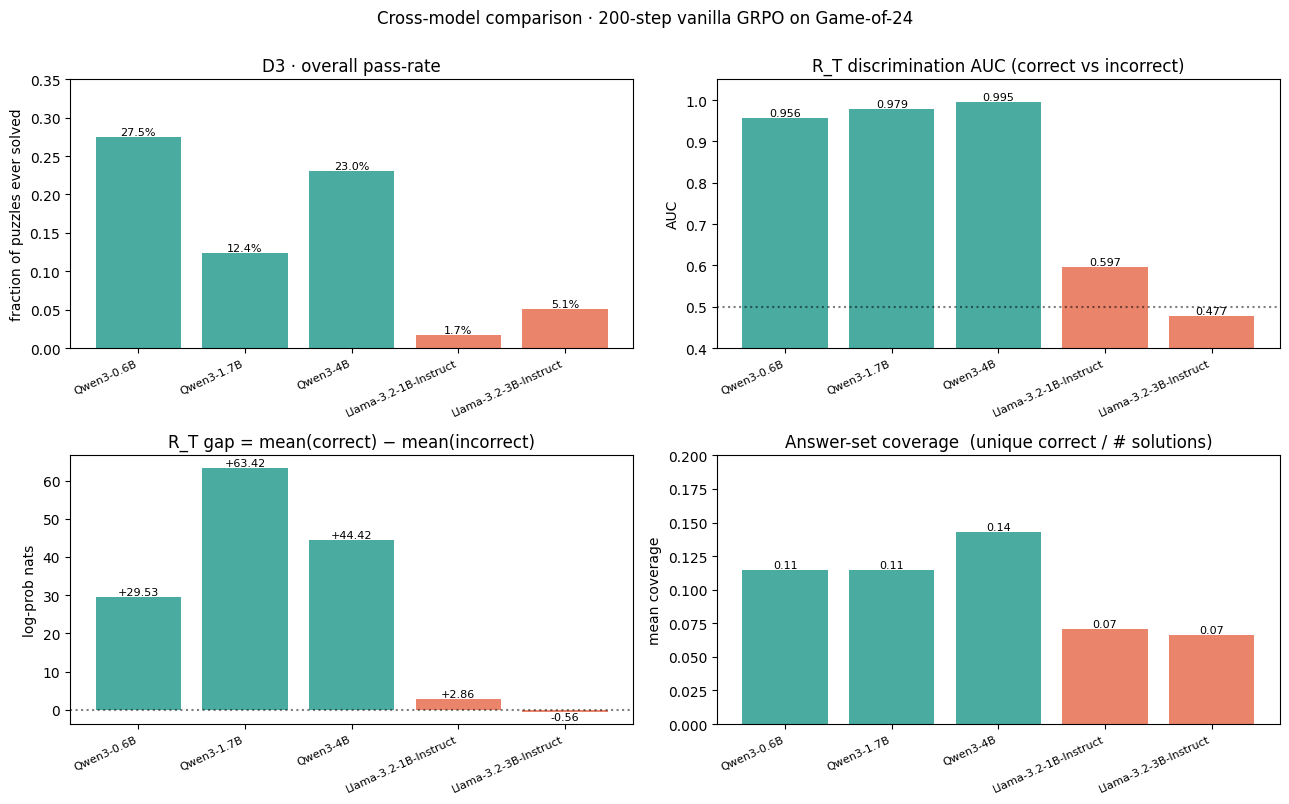


Takeaways:
  • Qwen3 family solves 21.0% of puzzles (overall); Llama-3.2-Instruct family solves 3.4%.
  • R_T AUC: Qwen3 mean = 0.977,  Llama mean = 0.537.
    → Decoding reward is a strong correctness proxy on Qwen3 (AUC ≥ 0.96); on Llama it's near chance (AUC ≈ 0.54), driven by too few correct rollouts (n_correct=[6, 20]).
  • Length confound: incorrect rollouts are longer than correct ones on every Qwen model (Δ = Qwen3-0.6B: +129, Qwen3-1.7B: +116, Qwen3-4B: +122).
  • Edit-distance of correct CoTs at end of training is high (0.56 for Qwen); model has NOT collapsed to a single mode of solution.


In [18]:
# Result analysis
# Loads the cross-model summary written by `script/run_game24_sweep.sh` and
# turns it into three views:
#
#   1. A wide table of all metrics (one row per model)
#   2. A compact comparison table of the headline metrics
#   3. Bar plots comparing models on the four axes that matter:
#         (a) trajectory pass-rate           — D3
#         (b) R_T discrimination AUC         — decoding-reward validity
#         (c) R_T gap (correct − incorrect)  — magnitude of discrimination
#         (d) coverage of answer set         — diversity / mode collapse

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

result_dir = Path("logs/game24_sweep")

# ── 1. Load summary.csv ─────────────────────────────────────────────────────
summary = pd.read_csv(result_dir / "summary.csv")

# Order rows: Qwen by size, then Llama by size
def _model_sort_key(name: str):
    family = 0 if "Qwen" in name else 1
    size = float(next((tok.rstrip("BbInstruct.").rstrip("-")
                       for tok in name.split("-") if tok and tok[0].isdigit()), 0))
    return (family, size)

summary = (summary.sort_values("model", key=lambda s: s.map(_model_sort_key))
                  .reset_index(drop=True))
summary["short"] = summary["model"].str.split("/").str[-1]

# ── 2. Headline comparison table ────────────────────────────────────────────
headline_cols = [
    ("short",                  "model"),
    ("train_seconds",          "train_s"),
    ("n_rollouts",             "n_roll"),
    ("d3_passrate_overall",    "passrate"),
    ("d3_passrate_hard (≤2)",  "pass_hard"),
    ("d1_mean_tokens_last",    "tok_last"),
    ("d1_edit_distance_last",  "edit_last"),
    ("coverage_mean",          "cover"),
    ("R_T_correct_mean",       "R_T+"),
    ("R_T_incorrect_mean",     "R_T−"),
    ("R_T_gap",                "gap"),
    ("R_T_auc",                "AUC"),
    ("R_T_cohens_d",           "d"),
    ("R_per_token_auc",        "AUC/tok"),
    ("dr_n_correct",           "n_corr"),
    ("len_correct_mean",       "len_corr"),
    ("len_incorrect_mean",     "len_inc"),
]
hdf = summary[[c for c, _ in headline_cols]].copy()
hdf.columns = [name for _, name in headline_cols]
fmt_map = {"train_s": "{:.0f}", "passrate": "{:.1%}", "pass_hard": "{:.1%}",
           "tok_last": "{:.0f}", "edit_last": "{:.2f}", "cover": "{:.2f}",
           "R_T+": "{:+.2f}", "R_T−": "{:+.2f}", "gap": "{:+.2f}",
           "AUC": "{:.3f}", "d": "{:+.2f}", "AUC/tok": "{:.3f}",
           "len_corr": "{:.0f}", "len_inc": "{:.0f}"}
for col, fmt in fmt_map.items():
    if col in hdf:
        hdf[col] = hdf[col].apply(lambda v, f=fmt: f.format(v) if pd.notna(v) else "—")
print("Headline metrics:")
print(hdf.to_string(index=False))


# ── 3. Bar comparison plots ─────────────────────────────────────────────────
def _bar(ax, ycol, title, ylabel, *, ylim=None, percent=False,
         h_at=None, fmt="{:.2f}"):
    x = np.arange(len(summary))
    y = summary[ycol].to_numpy(dtype=float)
    colors = ["#2a9d8f" if "Qwen" in m else "#e76f51" for m in summary["model"]]
    bars = ax.bar(x, y, color=colors, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(summary["short"], rotation=25, ha="right", fontsize=8)
    ax.set_title(title); ax.set_ylabel(ylabel)
    if ylim is not None:
        ax.set_ylim(*ylim)
    if h_at is not None:
        ax.axhline(h_at, color="k", linestyle=":", alpha=0.5)
    for b, v in zip(bars, y):
        if np.isnan(v): continue
        label = f"{v*100:.1f}%" if percent else fmt.format(v)
        ax.text(b.get_x() + b.get_width() / 2, v, label,
                ha="center", va="bottom" if v >= 0 else "top", fontsize=8)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
_bar(axes[0, 0], "d3_passrate_overall", "D3 · overall pass-rate",
     "fraction of puzzles ever solved", ylim=(0, max(0.35, summary.d3_passrate_overall.max() * 1.2)),
     percent=True)
_bar(axes[0, 1], "R_T_auc", "R_T discrimination AUC (correct vs incorrect)",
     "AUC", ylim=(0.4, 1.05), h_at=0.5, fmt="{:.3f}")
_bar(axes[1, 0], "R_T_gap", "R_T gap = mean(correct) − mean(incorrect)",
     "log-prob nats", h_at=0, fmt="{:+.2f}")
_bar(axes[1, 1], "coverage_mean", "Answer-set coverage  (unique correct / # solutions)",
     "mean coverage", ylim=(0, max(0.2, summary.coverage_mean.max() * 1.2)),
     fmt="{:.2f}")
fig.suptitle("Cross-model comparison · 200-step vanilla GRPO on Game-of-24", y=1.00)
plt.tight_layout(); plt.show()


# ── 4. Headline takeaways printed inline ────────────────────────────────────
def _row(model_substring):
    sub = summary[summary["model"].str.contains(model_substring, regex=False)]
    return sub.iloc[0] if len(sub) else None

print("\nTakeaways:")
qwen = summary[summary["model"].str.startswith("Qwen")]
llama = summary[summary["model"].str.startswith("meta-llama")]

print(f"  • Qwen3 family solves {qwen.d3_passrate_overall.mean():.1%} of puzzles "
      f"(overall); Llama-3.2-Instruct family solves {llama.d3_passrate_overall.mean():.1%}.")
print(f"  • R_T AUC: Qwen3 mean = {qwen.R_T_auc.mean():.3f},  "
      f"Llama mean = {llama.R_T_auc.mean():.3f}.")
print(f"    → Decoding reward is a strong correctness proxy on Qwen3 "
      f"(AUC ≥ {qwen.R_T_auc.min():.2f}); on Llama it's near chance "
      f"(AUC ≈ {llama.R_T_auc.mean():.2f}), driven by too few correct rollouts "
      f"(n_correct={list(llama.dr_n_correct)}).")
print(f"  • Length confound: incorrect rollouts are longer than correct ones "
      f"on every Qwen model "
      f"(Δ = "
      f"{', '.join(f'{r.short}: {r.len_incorrect_mean - r.len_correct_mean:+.0f}' for _,r in qwen.iterrows())}).")
print(f"  • Edit-distance of correct CoTs at end of training is high "
      f"({qwen.d1_edit_distance_last.mean():.2f} for Qwen); model has NOT collapsed "
      f"to a single mode of solution.")

In [ ]:
# 3 places where empirical comparison against GRPO baseline would be valuable: 

# (1). CoT length, here we expect the learned CoT to be much shorter
# (2). Solving the hard case: when conventional GRPO fails completely, new algo. succeed (because it has "correct answer" pulling force)
# (3). Diversity: with the diverse buffer, I expect the new algorithm to find more diverse solutions
#    - Here we want to be careful, technically it's impossible to "learn 10 responses to one query" for an LLM
#    - Unless we have the 10 responses to reside on top of the model's logits table. This can only be achieved
#    - by randomly sampling correct answers & prefixes, which continually push these "correct" responses up the 
#    - ranking (logits) table

# Experiment on MBE velocity reward + GRPO


In [ ]:
# The "Drop in pass rate" as model size grows is interesting, it produces a contradictory picture: 
# - bigger model lag behind smaller model, when operating under same CoT budget
# - fixing this dillema is worth pursuing
